Task Description: Fe Deficiency detection based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm) in 3 following modes:
#### 1) include all Wavelengths (from X397.32 to X1003.58 is included)
#### 2) remove nosiy Wavelengths (from X449.35 to X951.17 is included)
#### 3) 9 SHAP Features in 1&2 (Remember to Remove "reduced-related" codes when execute these states)

##### <font color=red> The SHAP plots are for class [1] which is "Fe deficiency" here </font>

#### Methods
- Logistic Regression (Linear)
- Random Forest

#### Test States
- Auto --> 1) All 2) Some
- C prime --> 1) All 2) Some

In [2]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()


#### Load and Preprocess
- Drop the 'Leaf' column as it provides no classification information (it has the same value 'YL' for all rows)
- Encode the 'Thesis' column (the ground-truth label)
- Separate the dataset into features and labels
- check class imbalance 1) in the whole dataset 2) per each plant
- Check for missing values in the entire DataFrame (There was none)
- Feature selection - Get feature importances using Random Forest ---> <font color=red> Keep them </font>
- Scale the feature values (Columns here)
##### <font color=red> Watch the reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions) for execution </font>

In [1]:
# Step 1: Load the dataset
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# Step 2: Preprocess the data
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])


# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X = data.iloc[:, 3:] 
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths
X = data.iloc[:, 21:190]

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
### All Wavelengths###
                #### Logistic Regression ###
# Original Dataset, All Features, Auto Split, Logistic Regression
# desired_columns = ['X717.54','X714.55', 'X711.56', 'X720.54', 'X723.53', 'X726.53', 'X708.57', 'X985.05', 'X997.40']
# Original Dataset, Some Features, Auto Split, Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X750.54', 'X708.57', 'X720.54', 'X738.53', 'X705.57', 'X905.18', 'X723.53']
# Original Dataset, All Features, C Prime Split, Logistic Regression
# desired_columns = ['X985.05', 'X997.40', 'X994.31', 'X978.88', 'X1000.49', 'X988.13', 'X972.71', 'X981.96', 'X819.95']
# Original Dataset, Some Features, C Prime Split, Logistic Regression
# desired_columns = ['X714.55', 'X905.18', 'X711.56', 'X908.24', 'X708.57', 'X819.95', 'X822.98', 'X705.57', 'X750.54']
            #### Random Forest###
# Original Dataset, All Features, Auto Split, RandomForest
# desired_columns = ['X702.58', 'X708.57', 'X711.56', 'X699.60', 'X613.38', 'X554.43', 'X586.80', 'X654.89', 'X690.64']
# Original Dataset, Some Features, Auto Split, RandomForest
# desired_columns = ['X714.55', 'X702.58', 'X711.56', 'X708.57', 'X705.57', 'X699.60', 'X566.18', 'X589.75', 'X580.90']
# Original Dataset, All Features, C Prime Split, RandomForest
# desired_columns = ['X702.58', 'X708.57', 'X699.60', 'X711.56', 'X726.53', 'X714.55', 'X554.43', 'X705.57', 'X586.80']
# Original Dataset, Some Features, C Prime Split, RandomForest
# desired_columns = ['X714.55', 'X702.58', 'X705.57', 'X708.57', 'X699.60', 'X711.56', 'X566.18', 'X589.75', 'X613.38']


### Trimmed Wavelengths ###
            #### Logistic Regression ###
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# Original Dataset, All Features, Auto Split, Logistic Regression
# desired_columns = ['X717.54', 'X714.55', 'X711.56', 'X720.54', 'X723.53', 'X708.57', 'X726.53', 'X729.53', 'X705.57']
# Original Dataset, Some Features, Auto Split, Logistic Regression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X708.57', 'X720.54', 'X723.53', 'X705.57', 'X702.58', 'X753.55']
# Original Dataset, All Features, C Prime Split, Logistic Regression
# desired_columns = ['X941.95', 'X819.95', 'X714.55', 'X717.54', 'X822.98', 'X948.10', 'X945.02', 'X711.56', 'X729.53']
# Original Dataset, Some Features, C Prime Split, Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X717.54', 'X708.57', 'X753.55', 'X756.56', 'X705.57', 'X822.98', 'X807.84']
            #### Random Forest###
# Original Dataset, All Features, Auto Split, RandomForest
# desired_columns = ['X542.68', 'X708.57', 'X702.58', 'X545.62', 'X569.12', 'X557.36', 'X699.60', 'X711.56', 'X536.82']
# Original Dataset, Some Features, Auto Split, RandomForest
# desired_columns = ['X711.56', 'X708.57', 'X705.57', 'X699.60', 'X717.54', 'X714.55', 'X539.75', 'X702.58', 'X554.43']
# Original Dataset, All Features, C Prime Split, RandomForest
# desired_columns = ['X702.58', 'X714.55', 'X711.56', 'X705.57', 'X708.57', 'X542.68', 'X717.54', 'X563.24', 'X720.54']
# Original Dataset, Some Features, C Prime Split, RandomForest
# desired_columns = ['X711.56', 'X708.57', 'X702.58', 'X717.54', 'X705.57', 'X714.55', 'X699.60', 'X563.24', 'X545.62']

# X = data[desired_columns]
# 😎😎😎😎😎😎 END OF new line

y = data['Thesis']
feature_names = X.columns.tolist()
print(feature_names)
# Check the distribution/imbalance of the target variable
class_distribution = data['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# Encode the 'Thesis' column
le = LabelEncoder()
y = le.fit_transform(y)

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced .columns.tolist()
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)
X_scaled.shape


NameError: name 'pd' is not defined

#### Very important: Check if encoded labels are consistant in original and each of the tested datasets

In [89]:
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")


Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1


### <font color=red> Disputed Cell! </font>
The following cell is related to "train & test" split which is under discussion
- Plan A/Auto: Blindly trust "train_test_split()" function
- Plan B: Manually, decompose the dataset based on plant type
- Plan C: <font color=red> 1) Use the train_test_split function to shuffle and split the data for each plant species separately. The split is set to 75% for training and 25% for testing --> each plant species has its own shuffled and split data, 2) Combine the Splits: combine the training subsets of (1) into a single training set and the test subsets into a single test set. </font>

In [108]:
# # Step 3: Train-Test Split

# #Plan A/ Auto
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)


# # # Common between plan B&C
# # # Grouping the data by plant using X_scaled and y
# # plant_groups_scaled = {
# #     "Plant1": (X_scaled[0:36], y[0:36]),
# #     "Plant2": (X_scaled[36:72], y[36:72]),
# #     "Plant3": (X_scaled[72:108], y[72:108]),
# #     "Plant4": (X_scaled[108:144], y[108:144])
# # }


# # # Assess the Similarity of Data Points
# # for plant, group_data in plant_groups_scaled.items():
# #     # check Class Imabalance in each Plant
# #     class_distribution = pd.Series(group_data[1]).value_counts()
# #     print(f"Class Distribution for {plant}:")
# #     print(class_distribution)
# #     class_distribution.plot(kind='bar')
# #     plt.title(f'Class Distribution for {plant}')
# #     plt.xlabel('Class')
# #     plt.ylabel('Frequency')
# #     plt.show()

# #     plant_features = group_data[0]
# #     plant_target = group_data[1]
# #     print(f"{plant} - Features Shape: {plant_features.shape}, Target Shape: {plant_target.shape}")

# #     # Calculate pairwise distances within the plant
# #     distances_within_plant = euclidean_distances(plant_features)
# #     np.fill_diagonal(distances_within_plant, np.nan)
    
# #     # Flatten distances to analyze distribution
# #     distances_flat_within_plant = distances_within_plant[np.triu_indices_from(distances_within_plant, k=1)]
# #     print("distances_within_plant.shape is",distances_within_plant.shape)
# #     print("distances_flat_within_plant.shape is",distances_flat_within_plant.shape)
# #     # Statistical measures
# #     mean_distance = np.nanmean(distances_flat_within_plant)
# #     std_distance = np.nanstd(distances_flat_within_plant)
# #     var_distance = np.nanvar(distances_flat_within_plant)
    
# #     print(f"{plant} - Mean Distance: {mean_distance}, Std Distance: {std_distance}, Var Distance: {var_distance}")
    
# #     # Visualize histogram of distances within the plant
# #     plt.figure(figsize=(10, 6))
# #     sns.histplot(distances_flat_within_plant, bins=20, kde=True)
# #     plt.title(f'Distribution of Pairwise Distances within {plant}')
# #     plt.xlabel('Distance')
# #     plt.ylabel('Frequency')
# #     plt.show()
    
# #     # PCA Scatter Plot for feature relationships within the plant
# #     pca = PCA(n_components=2)
# #     pca_result = pca.fit_transform(plant_features)
# #     plt.figure(figsize=(10, 6))
# #     plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
# #     plt.title(f'PCA Scatter Plot for {plant}')
# #     plt.xlabel('PCA Component 1')
# #     plt.ylabel('PCA Component 2')
# #     plt.show()
# # //////////////////////////////////////////////

# # # Plan B
# # # Concatenate the features and targets for Plants 1, 2, and 3 for the training set
# # X_train = np.concatenate([plant_groups_scaled["Plant1"][0], plant_groups_scaled["Plant2"][0], plant_groups_scaled["Plant3"][0]], axis=0)
# # y_train = np.concatenate([plant_groups_scaled["Plant1"][1], plant_groups_scaled["Plant2"][1], plant_groups_scaled["Plant3"][1]], axis=0)
# # # Use Plant 4 data for the test set
# # X_test = plant_groups_scaled["Plant4"][0]
# # y_test = plant_groups_scaled["Plant4"][1]
# # # Confirm the shape of the train and test sets
# # print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
# # print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# # # Plan C
# # X_train_list = []
# # y_train_list = []
# # X_test_list = []
# # y_test_list = []
# # # Iterate over each plant species
# # for plant in plant_groups_scaled.keys():
# #     X = plant_groups_scaled[plant][0]
# #     y = plant_groups_scaled[plant][1]
    
# #     # Split the data for each plant species (e.g., 75% train, 25% test)
# #     X_train_plant, X_test_plant, y_train_plant, y_test_plant = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=42)
    
# #     # Append to the respective lists
# #     X_train_list.append(X_train_plant)
# #     y_train_list.append(y_train_plant)
# #     X_test_list.append(X_test_plant)
# #     y_test_list.append(y_test_plant)

# # # Concatenate the lists to form the final train and test sets
# # X_train = np.concatenate(X_train_list, axis=0)
# # y_train = np.concatenate(y_train_list, axis=0)
# # X_test = np.concatenate(X_test_list, axis=0)
# # y_test = np.concatenate(y_test_list, axis=0)

# # # Shuffle the train and test sets to remove any order-based bias
# # X_train, y_train = shuffle(X_train, y_train, random_state=42)




# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> Standard Logistic Regression </font>

In [110]:
# ### Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression ###
# param_grid_lr = {
#     'C': [0.01, 0.1, 1, 10, 30],
#     'penalty': ['l2'],
#     'solver': ['lbfgs', 'liblinear', 'sag']
# }
# random_state= 42
# grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3,random_state=random_state), param_grid_lr, cv=5, scoring='accuracy')
# grid_search_lr.fit(X_train, y_train)
# best_params_lr = grid_search_lr.best_params_
# print("Best parameters for Logistic Regression:", best_params_lr)

# # Print Cross-Validation Scores from GridSearchCV
# cv_results = pd.DataFrame(grid_search_lr.cv_results_)
# print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# # Initialize the best logistic regression model
# model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# # # Perform cross-validation
# # cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
# # print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
# # print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# # Train the model on the entire training set
# model.fit(X_train, y_train)

# # Extract coefficients and intercept
# coefficients = model.coef_[0]  # For binary classification; adjust for multiclass
# intercept = model.intercept_[0]  # For binary classification; adjust for multiclass
# # Print coefficients and intercept with feature names
# print("Intercept:", intercept)
# print("Coefficients:")
# for feature, coef in zip(feature_names, coefficients):
#     print(f"{feature}: {coef}")
# # Save the coefficients and intercept to a .txt file without rounding
# output_file = "feature_coefficients_exact.txt"
# with open(output_file, "w") as f:
#     f.write(f"Intercept: {intercept}\n")
#     f.write("Coefficients:\n")
#     for feature, coef in zip(feature_names, coefficients):
#         f.write(f"{feature}: {coef}\n")
# print(f"Exact coefficients and intercept saved to {output_file}")



# # Make predictions on the test set
# y_pred = model.predict(X_test)

# # Model Evaluation for Standard Logistic Regression
# print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_test, y_pred))
# print("Test Set Classification Report:")
# print(classification_report(y_test, y_pred))
# # Confusion Matrix
# conf_matrix = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


# # NEW: SHAP ANALYSIS
# # Use LinearExplainer for logistic regression
# explainer_llr = shap.LinearExplainer(model, X_train)
# # Calculate SHAP values
# shap_values_llr = explainer_llr.shap_values(X_test)
# print("Linear Logistic Regression shap_values shape is", np.shape(shap_values_llr))
# # Ensure base_values is an array
# base_values_llr = np.full(shap_values_llr.shape[0], explainer_llr.expected_value)
# # Create an Explanation object
# shap_values_llr_explanation = shap.Explanation(
#     shap_values_llr,
#     base_values=base_values_llr,
#     data=X_test,
#     # feature_names = feature_names_reduced
#     feature_names=feature_names
# )
# # Generate SHAP plots
# # Summary Plot
# shap.summary_plot(shap_values_llr, X_test, feature_names=feature_names)
# # shap.summary_plot(shap_values_llr, X_test, feature_names=feature_names_reduced)
# # Bar Plot
# shap.plots.bar(shap_values_llr_explanation, max_display=10)
# # Beeswarm Plot
# shap.plots.beeswarm(shap_values_llr_explanation)
# print(shap_values_llr_explanation)
# # Waterfall Plot for the first instance
# shap.plots.waterfall(shap_values_llr_explanation[1])


# # # Initialize the LIME explainer
# # explainer_lime = LimeTabularExplainer(X_train, feature_names=feature_names_reduced, class_names=["Fe Sufficient", "Fe Deficient"], mode='classification')
# # # Choose an instance to explain
# # i = 0  # Index of the instance you want to explain
# # # Generate the explanation
# # exp = explainer_lime.explain_instance(X_test[i], model.predict_proba, num_features=10)
# # # Show the explanation
# # exp.show_in_notebook(show_table=True)

# # # Plot LIME explanation
# # exp.as_pyplot_figure()
# # plt.title(f"LIME Explanation for Instance {i}")
# # plt.show()

#### <font color=green> Polynomial Logistic Regression </font>

In [4]:
# ### Polynomial Logistic Regression ###
# # Create polynomial features
# poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
# X_poly = poly.fit_transform(X_train)

# # Hyperparameter Tuning and Cross-Validation for Polynomial Logistic Regression
# param_grid_poly = {
#     'C': [0.01, 0.1, 1, 10, 30],
#     'penalty': ['l2'],
#     'solver': ['lbfgs', 'liblinear', 'sag']
# }
# random_state = 42
# grid_search_poly = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state), param_grid_poly, cv=5, scoring='accuracy')
# grid_search_poly.fit(X_poly, y_train)
# best_params_poly = grid_search_poly.best_params_
# print("Best parameters for Polynomial Logistic Regression:", best_params_poly)

# # Print Cross-Validation Scores from GridSearchCV
# cv_results_poly = pd.DataFrame(grid_search_poly.cv_results_)
# print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_poly[['mean_test_score', 'std_test_score', 'params']])

# # Initialize the best polynomial logistic regression model
# model_poly = LogisticRegression(**best_params_poly,max_iter=5000, tol=1e-3,random_state=random_state)

# # Train the model on the entire training set
# model_poly.fit(X_poly, y_train)

# # Make predictions on the test set
# y_pred_poly = model_poly.predict(poly.transform(X_test))

# # Model Evaluation for Polynomial Logistic Regression
# print("\nPolynomial Logistic Regression - Test Set Accuracy:", accuracy_score(y_test, y_pred_poly))
# print("Test Set Classification Report:")
# print(classification_report(y_test, y_pred_poly))

# # Confusion Matrix
# conf_matrix_poly = confusion_matrix(y_test, y_pred_poly)
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix_poly, annot=True, fmt="d", cmap="Blues", xticklabels=["Fe Sufficient", "Fe Deficient"], yticklabels=["Fe Sufficient", "Fe Deficient"])
# plt.title("Confusion Matrix - Polynomial Logistic Regression")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


# # Use a smaller sample of the training dataset for SHAP analysis
# sample_size = 100  # Adjust the sample size according to your memory capacity
# X_sample = X_poly[:sample_size]
# y_sample = y_train[:sample_size]

# # SHAP Analysis
# # Use KernelExplainer for polynomial logistic regression with a subset of samples
# explainer_ker = shap.KernelExplainer(model_poly.predict, X_sample)

# # Calculate SHAP values for a subset of test data
# shap_values_ker = explainer_ker.shap_values(poly.transform(X_test)[:sample_size])
# print("Polynomial Logistic Regression shap_values shape is", np.shape(shap_values_ker))

# # Ensure base_values is an array
# base_values_ker = np.full(len(shap_values_ker), explainer_ker.expected_value)

# # Create an Explanation object
# shap_values_ker_explanation = shap.Explanation(
#     shap_values_ker,
#     base_values=base_values_ker,
#     data=poly.transform(X_test)[:sample_size],
#     feature_names=poly.get_feature_names_out()
# )

# # Generate SHAP plots
# # Summary Plot
# shap.summary_plot(shap_values_ker, poly.transform(X_test)[:sample_size], feature_names=poly.get_feature_names_out())

# # Bar Plot
# shap.plots.bar(shap_values_ker_explanation)

# # Beeswarm Plot
# shap.plots.beeswarm(shap_values_ker_explanation)

# # Waterfall Plot for the first instance
# shap.plots.waterfall(shap_values_ker_explanation[0])


In [29]:
# #Execute this when we have all features
# X_sample = X_poly
# y_sample = y_train

# # SHAP Analysis
# # Use LinearExplainer for polynomial logistic regression with a subset of samples
# explainer_llr_poly = shap.LinearExplainer(model_poly, X_sample)
# # Calculate SHAP values for a subset of test data
# shap_values_llr = explainer_llr_poly.shap_values(poly.transform(X_test))
# print("Polynomial Logistic Regression shap_values shape is", np.shape(shap_values_llr))

# # Ensure base_values is an array
# base_values_llr = np.full(X_sample.shape[0], explainer_llr_poly.expected_value)

# # Create an Explanation object
# shap_values_llr_explanation = shap.Explanation(
#     shap_values_llr,
#     base_values=base_values_llr,
#     data=poly.transform(X_test),
#     feature_names=poly.get_feature_names_out()
# )

# # Generate SHAP plots
# # Summary Plot
# shap.summary_plot(shap_values_llr, poly.transform(X_test), feature_names=poly.get_feature_names_out())

# # Bar Plot
# shap.plots.bar(shap_values_llr_explanation)

# # Beeswarm Plot
# shap.plots.beeswarm(shap_values_llr_explanation)

# # Waterfall Plot for the first instance
# shap.plots.waterfall(shap_values_llr_explanation[0])


#### <font color=green> Random Forest </font>

In [ ]:
# ### Random Forest Classifier ###
# # Hyperparameter Tuning and Cross-Validation for Random Forest
# param_grid_rf = {
#     'n_estimators': [10, 50, 100, 200],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }
# # Set a random_state for reproducibility
# random_state = 42
# grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
# grid_search_rf.fit(X_train, y_train)
# best_params_rf = grid_search_rf.best_params_
# print("Best parameters for Random Forest:", best_params_rf)

# # Print Cross-Validation Scores from GridSearchCV
# cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
# print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# # Initialize the best Random Forest model
# rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# # Train the model on the entire training set
# rf_model.fit(X_train, y_train)

# # Make predictions on the test set
# y_pred_rf = rf_model.predict(X_test)

# # Model Evaluation for Random Forest
# print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_test, y_pred_rf))
# print("Test Set Classification Report:")
# print(classification_report(y_test, y_pred_rf))

# # Confusion Matrix
# conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues",  xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
# plt.title("Confusion Matrix - Random Forest")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # SHAP Analysis
# # Use TreeExplainer for Random Forest
# explainer_rf = shap.TreeExplainer(rf_model)

# # Calculate SHAP values
# shap_values_rf = explainer_rf.shap_values(X_test)
# print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# # Select the SHAP values for the positive class (class 1)
# shap_values_rf_selected = shap_values_rf[:, :, 1]
# # Print the shape of the resulting array
# print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# # Create an Explanation object
# shap_values_rf_explanation = shap.Explanation(
#     shap_values_rf_selected,
#     base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
#     data=X_test,
#     feature_names=feature_names
#     # feature_names=feature_names_reduced
# )

# # Generate SHAP plots
# # Summary Plot
# shap.summary_plot(shap_values_rf_explanation, X_test, feature_names=feature_names)
# # shap.summary_plot(shap_values_rf_explanation, X_test, feature_names=feature_names_reduced)
# # Bar Plot
# shap.plots.bar(shap_values_rf_explanation)

# # Beeswarm Plot
# shap.plots.beeswarm(shap_values_rf_explanation)

# # Waterfall Plot for the first instance
# shap.plots.waterfall(shap_values_rf_explanation[0])


#### Use the following cell as a <font color=red> "stand-alone Logistic Regression" </font> for plan C Prime split
#### run from the last cell each time, or the sizes will collapse and it will engender error!

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: 7.910098448167751
Coefficients:
X714.55: 3.47025875133792
X702.58: 2.0342155465166467
X705.57: 2.5934087198469533
X708.57: 3.1190807144185904
X699.60: 1.3181742702462262
X711.56: 3.28023681183556
X566.18: 0.5374356409602656
X589.75: 0.28502948860358124
X613.38: -0.01814930577683621

Logistic Regression - Test Set Accuracy: 0.9722222222222222
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.95      0.97        20

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



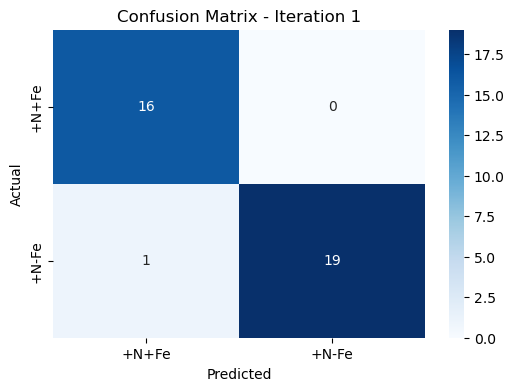

Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: 3.3304934932749357
Coefficients:
X714.55: 1.661336287834267
X702.58: 0.8977650709660899
X705.57: 1.1432696725696083
X708.57: 1.3650458673708885
X699.60: 0.6176683305225849
X711.56: 1.5269640428491575
X566.18: 0.3902423157479069
X589.75: 0.19595018531641092
X613.38: 0.08651509801710373

Logistic Regression - Test Set Accuracy: 0.9722222222222222
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      0.92      0.96        12

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



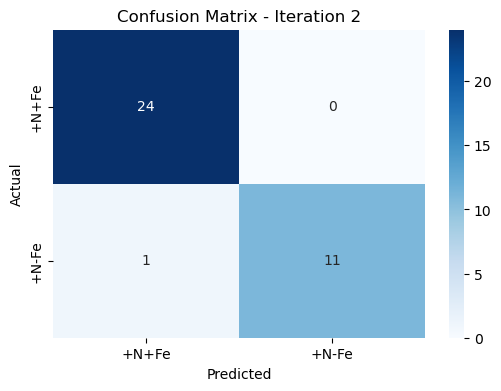

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: 6.683237100305266
Coefficients:
X714.55: 3.229463068263375
X702.58: 1.9817870757003357
X705.57: 2.5712110065753
X708.57: 3.040737154745933
X699.60: 1.2237679524701823
X711.56: 3.1769397121184495
X566.18: -0.12383693546379237
X589.75: -0.22128480133392747
X613.38: -0.45173654439225186

Logistic Regression - Test Set Accuracy: 1.0
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        20

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



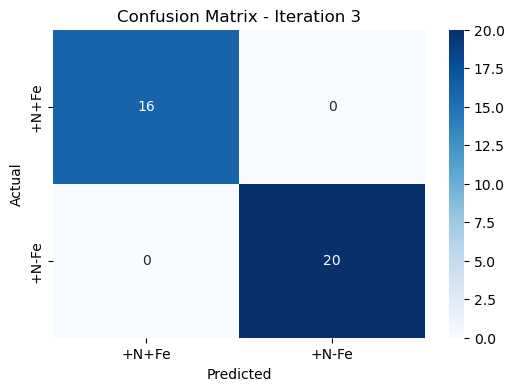

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Intercept: 7.0706289156145905
Coefficients:
X714.55: 3.2558299060773557
X702.58: 2.07568020492712
X705.57: 2.765432208213111
X708.57: 3.256700191995486
X699.60: 1.1820048345383984
X711.56: 3.3620775848613023
X566.18: 0.39800346893796873
X589.75: -0.11344466731758684
X613.38: -0.5480494424363598

Logistic Regression - Test Set Accuracy: 0.9722222222222222
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.95      0.97        20

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



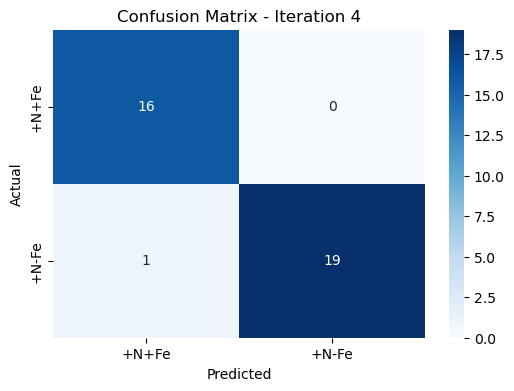


Average Accuracy Across 4 Iterations: 0.9791666666666667
All runs' coefficients and averaged results saved to feature_coefficients_all_runs_and_average.txt


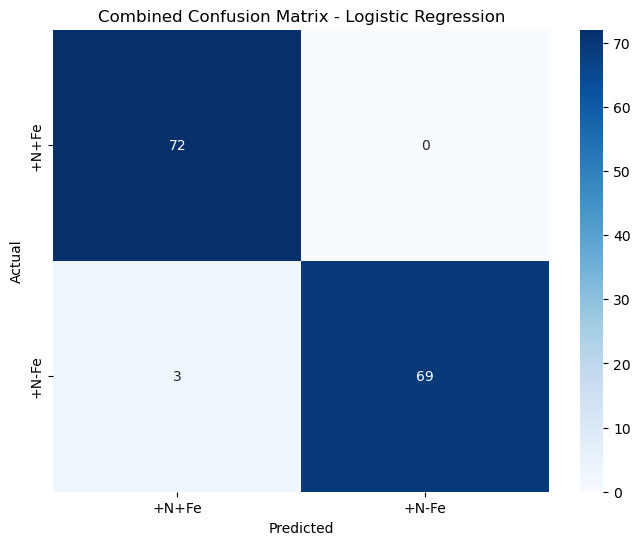


Overall Precision: 0.9791666666666666
Overall Recall: 0.9791666666666666
Overall F1-score: 0.9791666666666666


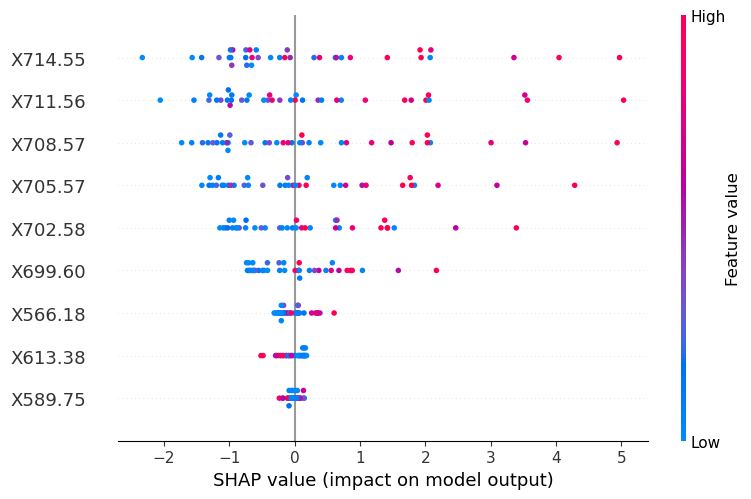

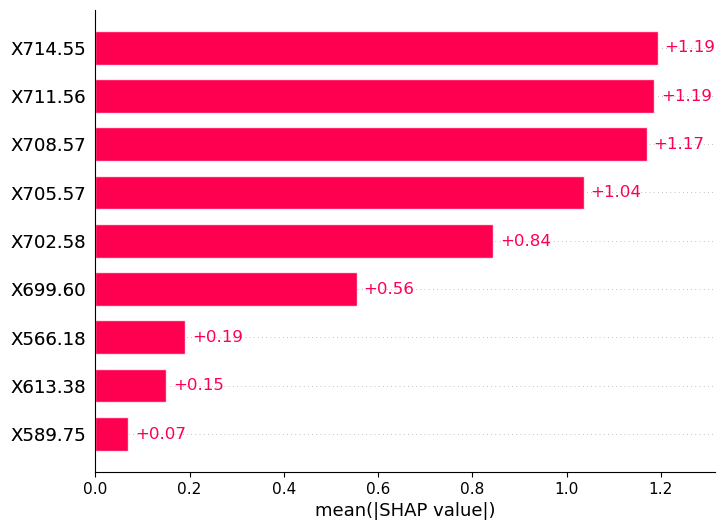

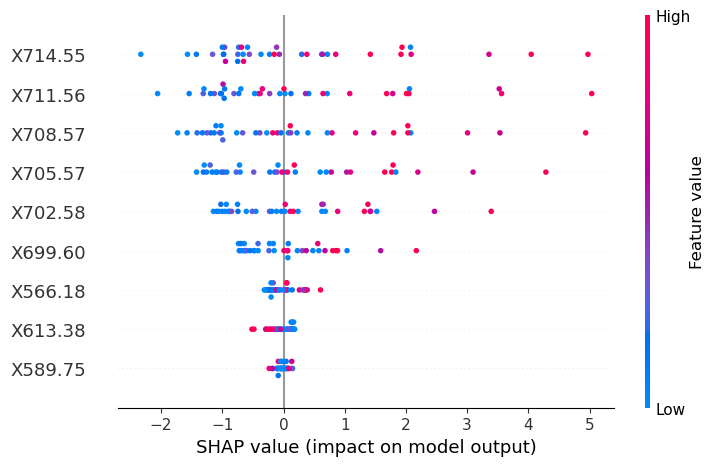

In [115]:
# Function to train and evaluate a model, and compute SHAP values
def train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names):
    # Define the parameter grid for Logistic Regression
    param_grid_lr = {
        'C': [0.01, 0.1, 1, 10, 30],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
    }

    # Initialize the Logistic Regression model
    lr_model = LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state)

    # Perform GridSearchCV with cross-validation
    grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=5, scoring='accuracy')
    grid_search_lr.fit(X_train, y_train)
    best_params_lr = grid_search_lr.best_params_
    print("Best parameters for Logistic Regression:", best_params_lr)

    # Train the best model on the entire training set
    best_lr_model = LogisticRegression(**best_params_lr, max_iter=1000, tol=1e-3, random_state=random_state)
    best_lr_model.fit(X_train, y_train)

    # Extract coefficients and intercept
    coefficients = best_lr_model.coef_[0]  # For binary classification; adjust for multiclass
    intercept = best_lr_model.intercept_[0]  # For binary classification; adjust for multiclass

    # Print coefficients and intercept with feature names
    print("Intercept:", intercept)
    print("Coefficients:")
    for feature, coef in zip(feature_names, coefficients):
        print(f"{feature}: {coef}")

    # Make predictions on the test set
    y_pred = best_lr_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print("\nLogistic Regression - Test Set Accuracy:", accuracy)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Calculate SHAP values
    explainer = shap.Explainer(best_lr_model, X_train)
    shap_values = explainer(X_test)
    return accuracy, conf_matrix, y_test, y_pred, shap_values, feature_names, intercept, coefficients


# Initialize random state
random_state = 42

# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}

# Shuffle the data for each plant once before starting the for loops
for plant in plant_groups_scaled.keys():
    X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
    plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# Lists to store accuracies, confusion matrices, predictions, SHAP values, intercepts, and coefficients from each iteration
accuracies = []
conf_matrices = []
all_y_true = []
all_y_pred = []
shap_values_list = []
all_intercepts = []
all_coefficients = []

# Number of splits
n_splits = 4

# Iterate to split the dataset
for i in range(n_splits):
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Iterate over each plant species
    for plant in plant_groups_scaled.keys():
        X = plant_groups_scaled[plant][0]
        y = plant_groups_scaled[plant][1]

        # Define the indices for the current split
        test_size = len(X) // n_splits
        test_indices = range(i * test_size, (i + 1) * test_size)
        train_indices = list(set(range(len(X))) - set(test_indices))

        # Split the data for the current iteration
        X_train_plant = X[train_indices]
        y_train_plant = y[train_indices]
        X_test_plant = X[test_indices]
        y_test_plant = y[test_indices]

        # Append to the respective lists
        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

    # Concatenate the lists to form the final train and test sets
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    # Shuffle the concatenated train and test sets to remove any order-based bias
    X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    # Train and evaluate the model, and get SHAP values
    accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names, intercept, coefficients = train_evaluate_shap(
        X_train, y_train, X_test, y_test, feature_names
    )

    # Append the current results to the lists
    accuracies.append(accuracy)
    conf_matrices.append(conf_matrix)
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    shap_values_list.append(shap_values)
    all_intercepts.append(intercept)
    all_coefficients.append(coefficients)

    # Plot the confusion matrix for each iteration
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - Iteration {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)
print("\nAverage Accuracy Across 4 Iterations:", average_accuracy)

# Combine confusion matrices by summing them up
combined_conf_matrix = np.sum(conf_matrices, axis=0)

# Calculate the averaged intercept and coefficients
averaged_intercept = np.mean(all_intercepts)
averaged_coefficients = np.mean(all_coefficients, axis=0)

# Save the results of each run and their average to a .txt file
output_file = "feature_coefficients_all_runs_and_average.txt"
with open(output_file, "w") as f:
    # Header
    f.write("Intercepts and Coefficients for Each Run:\n")
    f.write("======================================\n\n")

    # Write the results for each run
    for i, (intercept, coef_list) in enumerate(zip(all_intercepts, all_coefficients)):
        f.write(f"Run {i + 1}:\n")
        f.write(f"Intercept: {intercept}\n")
        f.write("Coefficients:\n")
        for feature, coef in zip(feature_names, coef_list):
            f.write(f"{feature}: {coef}\n")
        f.write("\n")  # Add a newline between runs

    # Write the averaged intercept and coefficients
    f.write("\nAveraged Intercept and Coefficients:\n")
    f.write("======================================\n")
    f.write(f"Averaged Intercept: {averaged_intercept}\n")
    f.write("Averaged Coefficients:\n")
    for feature, coef in zip(feature_names, averaged_coefficients):
        f.write(f"{feature}: {coef}\n")

print(f"All runs' coefficients and averaged results saved to {output_file}")

# Plot the combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Combined Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate precision, recall, and F1-score using the aggregated results
precision = precision_score(all_y_true, all_y_pred, average='micro')
recall = recall_score(all_y_true, all_y_pred, average='micro')
f1 = f1_score(all_y_true, all_y_pred, average='micro')

print(f"\nOverall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall F1-score: {f1}")

# Aggregate SHAP values
mean_shap_values = np.mean([sv.values for sv in shap_values_list], axis=0)
combined_base_values = np.mean([sv.base_values for sv in shap_values_list], axis=0)

# Create an Explanation object with combined SHAP values
combined_explanation = shap.Explanation(
    values=mean_shap_values,
    base_values=combined_base_values,
    data=X_test,
    feature_names=feature_names
)

# Generate SHAP plots for each class
# Summary Plot
shap.summary_plot(
    combined_explanation.values, 
    X_test, 
    feature_names=combined_explanation.feature_names
)


# Bar Plot
shap.plots.bar(
    shap.Explanation(
        values=combined_explanation.values,
        base_values=combined_explanation.base_values,
        data=X_test,
        feature_names=combined_explanation.feature_names
    ), max_display=10
)

# Beeswarm Plot
shap.plots.beeswarm(
    shap.Explanation(
        values=combined_explanation.values,
        base_values=combined_explanation.base_values,
        data=X_test,
        feature_names=combined_explanation.feature_names
    )
)


#### Use the following cell as a <font color=red> "stand-alone RandomForest" </font> for plan C Prime split
#### run from the last cell each time, or the sizes will collapse and it will engender error!

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)
Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}

Random Forest - Test Set Accuracy: 0.9444444444444444
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.90      0.95        20

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36

shap_values_rf's shape (36, 9, 2)


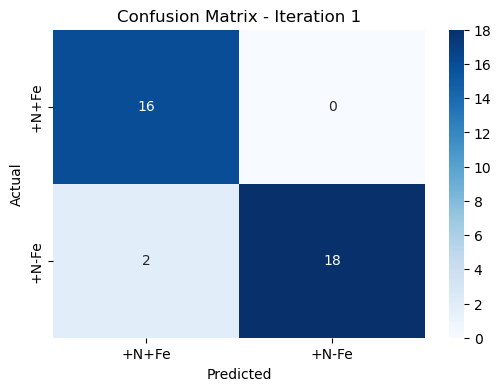

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)
Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}

Random Forest - Test Set Accuracy: 1.0
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        12

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

shap_values_rf's shape (36, 9, 2)


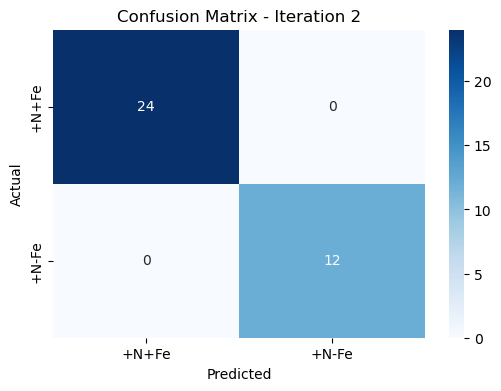

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)
Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Random Forest - Test Set Accuracy: 0.9722222222222222
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.95      1.00      0.98        20

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

shap_values_rf's shape (36, 9, 2)


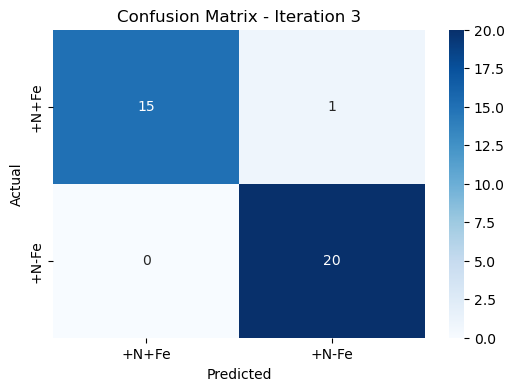

X_train shape: (108, 9), y_train shape: (108,)
X_test shape: (36, 9), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Random Forest - Test Set Accuracy: 0.9722222222222222
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.95      0.97        20

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

shap_values_rf's shape (36, 9, 2)


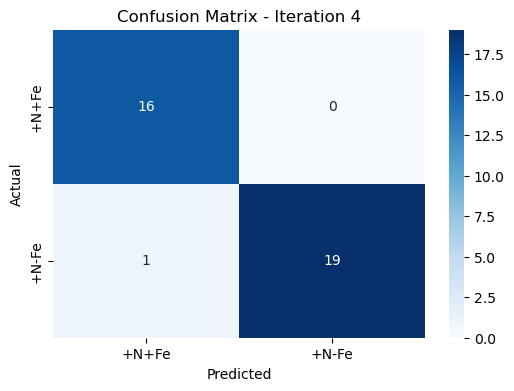


Average Accuracy Across 4 Iterations: 0.9722222222222222


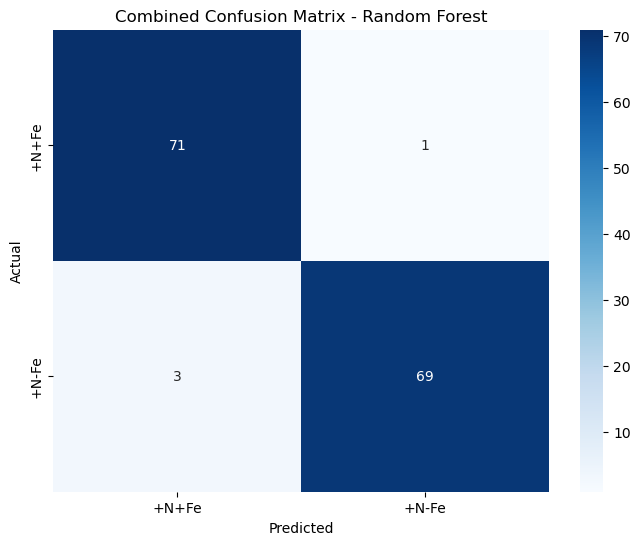


Overall Precision: 0.9722222222222222
Overall Recall: 0.9722222222222222
Overall F1-score: 0.9722222222222222
combined_base_values_rf's shape [0.48446759 0.51553241]
Generating SHAP plots


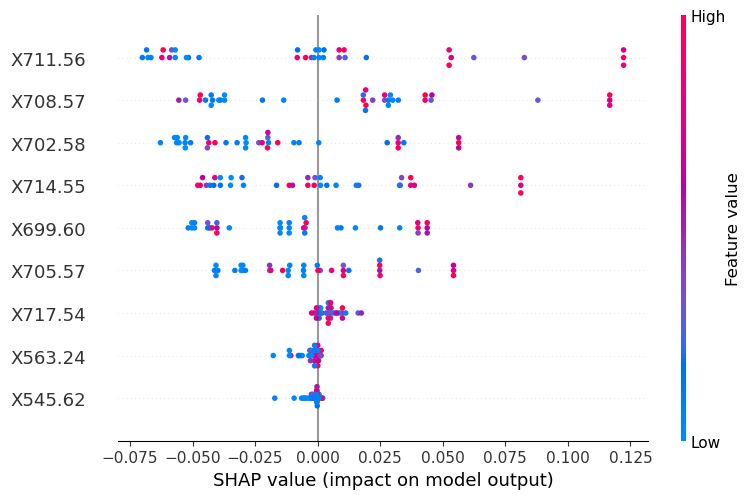

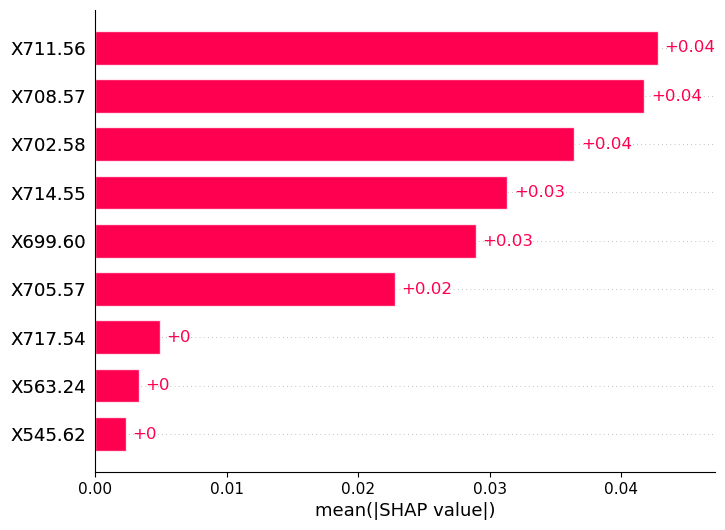

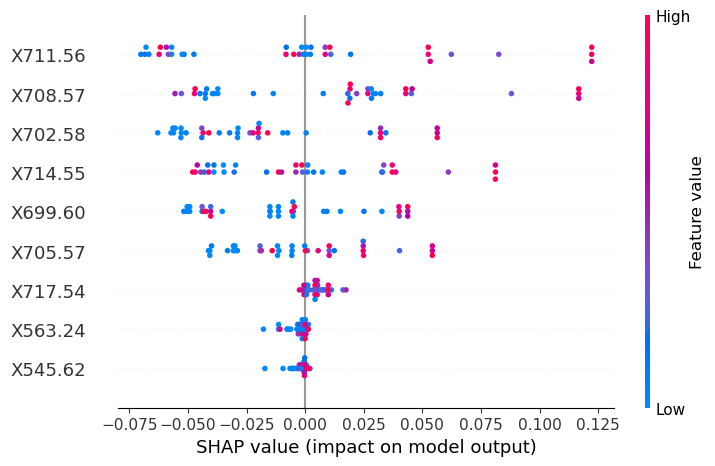

In [45]:
# Function to train and evaluate a model, and compute SHAP values
def train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names):
    # Define the parameter grid for Random Forest
    param_grid_rf = {
        'n_estimators': [10, 50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    random_state = 42

    # Perform GridSearchCV with cross-validation
    grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
    grid_search_rf.fit(X_train, y_train)
    best_params_rf = grid_search_rf.best_params_
    print("Best parameters for Random Forest:", best_params_rf)

    # Initialize the best Random Forest model
    best_rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)
    best_rf_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_rf = best_rf_model.predict(X_test)

    # Evaluate the model
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    print("\nRandom Forest - Test Set Accuracy:", accuracy_rf)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred_rf))

    # Confusion Matrix
    conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

    # Calculate SHAP values using TreeExplainer
    explainer_rf = shap.TreeExplainer(best_rf_model)
    shap_values_rf = explainer_rf.shap_values(X_test)
    print("shap_values_rf's shape", shap_values_rf.shape)
    return accuracy_rf, conf_matrix_rf, y_test, y_pred_rf, shap_values_rf, explainer_rf, feature_names

# Initialize random state
random_state = 42

# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}

# 😶😶😶😶😶😶😶😶😶😶😶😶
# Shuffle the data for each plant once before starting the for loops
for plant in plant_groups_scaled.keys():
    X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
    plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
accuracies_rf = []
conf_matrices_rf = []
all_y_true_rf = []
all_y_pred_rf = []
shap_values_list_rf = []
explainer_rf_list = []

# Number of splits
n_splits = 4

# Iterate to split the dataset
for i in range(n_splits):
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Iterate over each plant species
    for plant in plant_groups_scaled.keys():
        X = plant_groups_scaled[plant][0]
        y = plant_groups_scaled[plant][1]
        
        # Define the indices for the current split
        test_size = len(X) // n_splits
        test_indices = range(i * test_size, (i + 1) * test_size)
        train_indices = list(set(range(len(X))) - set(test_indices))
        
        # Split the data for the current iteration
        X_train_plant = X[train_indices]
        y_train_plant = y[train_indices]
        X_test_plant = X[test_indices]
        y_test_plant = y[test_indices]
        
        # Append to the respective lists
        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

    # Concatenate the lists to form the final train and test sets
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    # 😶😶😶😶😶😶😶😶😶😶😶😶
    # Shuffle the concatenated train and test sets to remove any order-based bias
    X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    
    # Confirm the shape of the train and test sets
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Train and evaluate the model, and get SHAP values
    accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names)
    # accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names_reduced)

    
    accuracies_rf.append(accuracy_rf)
    conf_matrices_rf.append(conf_matrix_rf)
    all_y_true_rf.extend(y_true_rf)
    all_y_pred_rf.extend(y_pred_rf)
    shap_values_list_rf.append(shap_values_rf)
    explainer_rf_list.append(explainer_rf)

    # Plot the confusion matrix for each iteration
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - Iteration {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Calculate the average accuracy
average_accuracy_rf = np.mean(accuracies_rf)
print("\nAverage Accuracy Across 4 Iterations:", average_accuracy_rf)

# Combine confusion matrices by summing them up
# Combine confusion matrices by summing them up
combined_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)

# Plot the combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Combined Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate precision, recall, and F1-score using the aggregated results
precision_rf = precision_score(all_y_true_rf, all_y_pred_rf, average='micro')
recall_rf = recall_score(all_y_true_rf, all_y_pred_rf, average='micro')
f1_rf = f1_score(all_y_true_rf, all_y_pred_rf, average='micro')

print(f"\nOverall Precision: {precision_rf}")
print(f"Overall Recall: {recall_rf}")
print(f"Overall F1-score: {f1_rf}")


# Aggregate SHAP values
mean_shap_values_rf = np.mean([sv for sv in shap_values_list_rf], axis=0)
combined_base_values_rf = np.mean([explainer.expected_value for explainer in explainer_rf_list], axis=0)
print("combined_base_values_rf's shape", combined_base_values_rf)


# Create an Explanation object with combined SHAP values
combined_explanation_rf = shap.Explanation(
    values=mean_shap_values_rf[:, :, 1],
    base_values=combined_base_values_rf,
    data=X_test,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)


# Generate SHAP plots for each class
print(f"Generating SHAP plots")
# Summary Plot
shap.summary_plot(combined_explanation_rf)
# Bar Plot
shap.plots.bar(combined_explanation_rf)
# Beeswarm Plot
shap.plots.beeswarm(combined_explanation_rf)
